In [4]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── High-resolution settings for paper figures ──────────────────────────────
DPI = 300
matplotlib.rcParams.update({
    'figure.dpi':        DPI,
    'savefig.dpi':       DPI,
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'lines.linewidth':   1.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

SUMMARY_DIR = Path('summary')
FIG_DIR     = SUMMARY_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete. Figures will be saved to:', FIG_DIR.resolve())

Setup complete. Figures will be saved to: /Users/mukaiyu/Desktop/mikrowordiverse/kmsa_2026spring_Algoverse/summary/figures


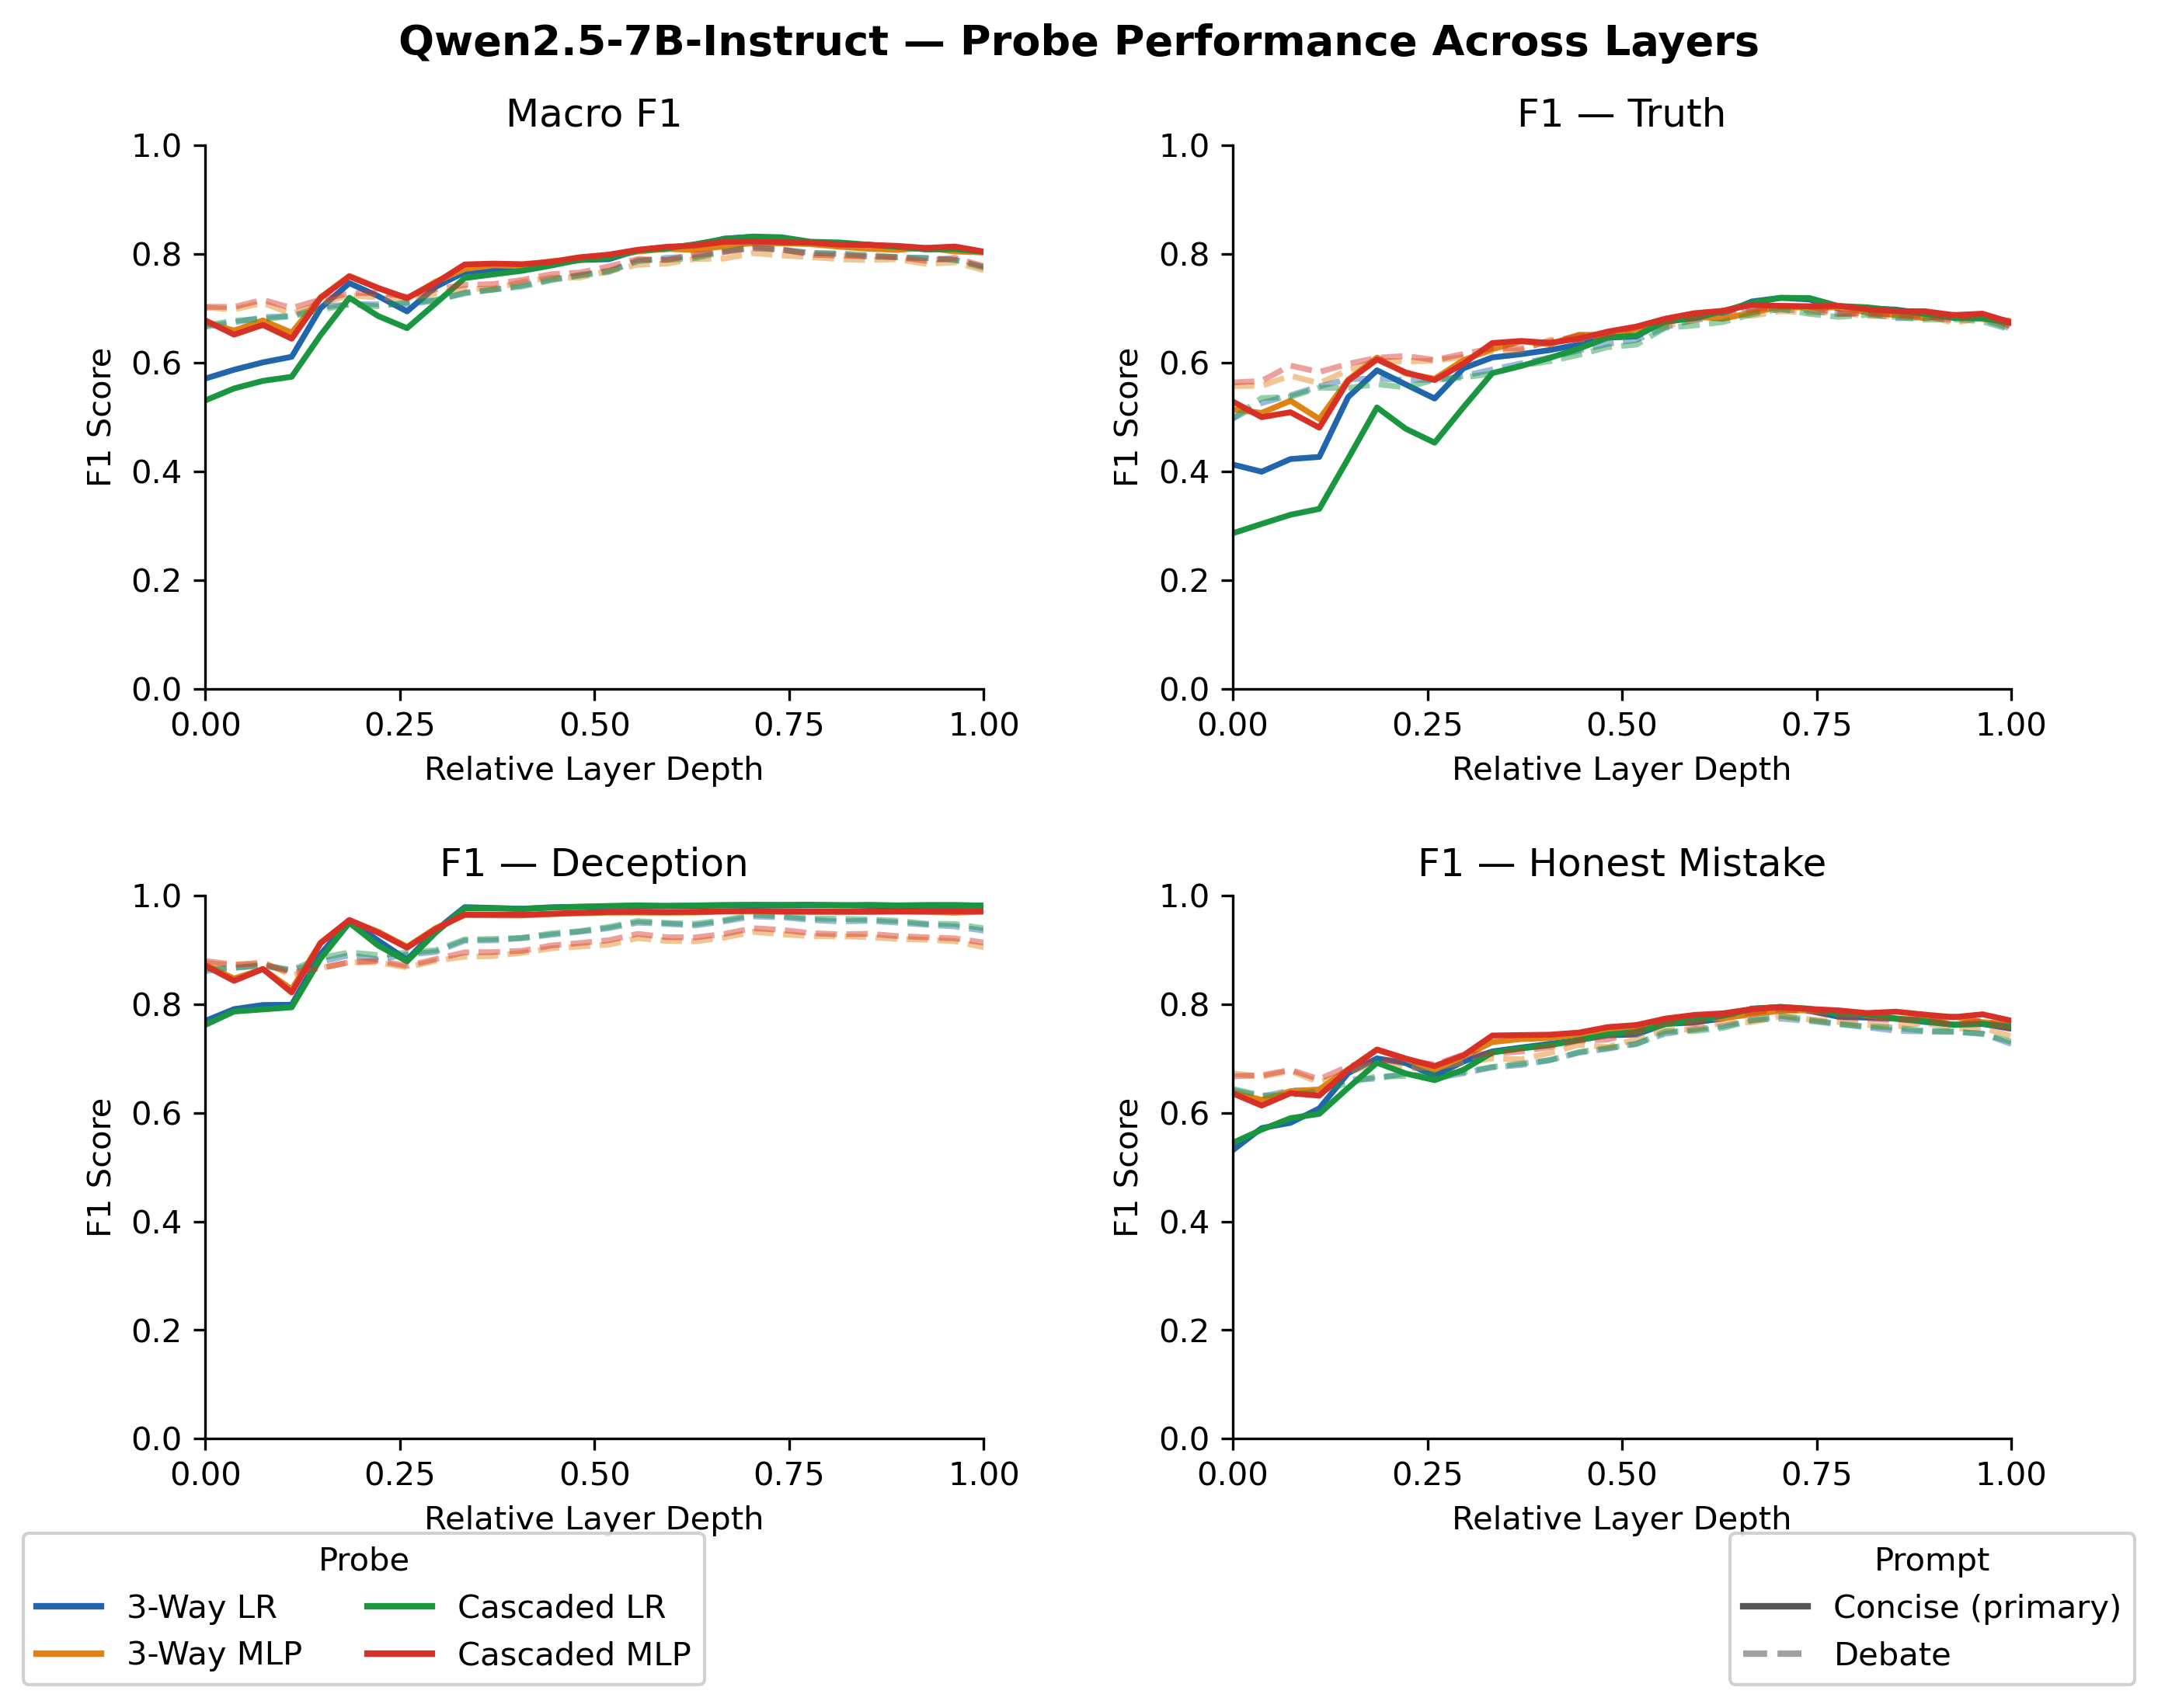

Saved: summary/figures/fig1_qwen25_probe_performance.png


In [5]:
# ── Figure 1: Qwen2.5-7B-Instruct — probe performance across layers ──────────
from matplotlib.lines import Line2D

PROBES = [
    ('3way_lr',      '3-Way LR',      '#2166AC'),
    ('3way_mlp',     '3-Way MLP',     '#E08214'),
    ('cascaded_lr',  'Cascaded LR',   '#1A9641'),
    ('cascaded_mlp', 'Cascaded MLP',  '#D73027'),
]
METRICS = [
    ('f1_macro',          'Macro F1'),
    ('f1_truth',          'F1 — Truth'),
    ('f1_deception',      'F1 — Deception'),
    ('f1_honest_mistake', 'F1 — Honest Mistake'),
]

def _load_q25(probe_key, prompt):
    df = pd.read_csv(SUMMARY_DIR / f'qwen2.5_{probe_key}_{prompt}.csv')
    df['rel_layer'] = df['layer'] / (len(df) - 1)
    return df

fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))
fig.subplots_adjust(hspace=0.38, wspace=0.32, bottom=0.16, top=0.90)

for ax, (col, title) in zip(axes.flat, METRICS):
    for probe_key, _, color in PROBES:
        df_c = _load_q25(probe_key, 'concise')
        df_d = _load_q25(probe_key, 'debate')
        ax.plot(df_c['rel_layer'], df_c[col], color=color, ls='-',  alpha=1.0,  lw=1.8)
        ax.plot(df_d['rel_layer'], df_d[col], color=color, ls='--', alpha=0.45, lw=1.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Relative Layer Depth', fontsize=10)
    ax.set_ylabel('F1 Score', fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))

fig.suptitle('Qwen2.5-7B-Instruct — Probe Performance Across Layers',
             fontsize=13, fontweight='bold', y=0.97)

# ── Two-part legend at bottom ────────────────────────────────────────────────
probe_handles = [
    Line2D([0], [0], color=c, lw=2, ls='-', label=lbl)
    for _, lbl, c in PROBES
]
style_handles = [
    Line2D([0], [0], color='#555555', lw=2, ls='-',  label='Concise (primary)'),
    Line2D([0], [0], color='#555555', lw=2, ls='--', alpha=0.55, label='Debate'),
]

fig.legend(handles=probe_handles,
           title='Probe', title_fontsize=10,
           ncols=2, loc='lower left',
           bbox_to_anchor=(0.04, 0.01), framealpha=0.9)
fig.legend(handles=style_handles,
           title='Prompt', title_fontsize=10,
           ncols=1, loc='lower right',
           bbox_to_anchor=(0.96, 0.01), framealpha=0.9)

save_path = FIG_DIR / 'fig1_qwen25_probe_performance.png'
fig.savefig(save_path, dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved:', save_path)


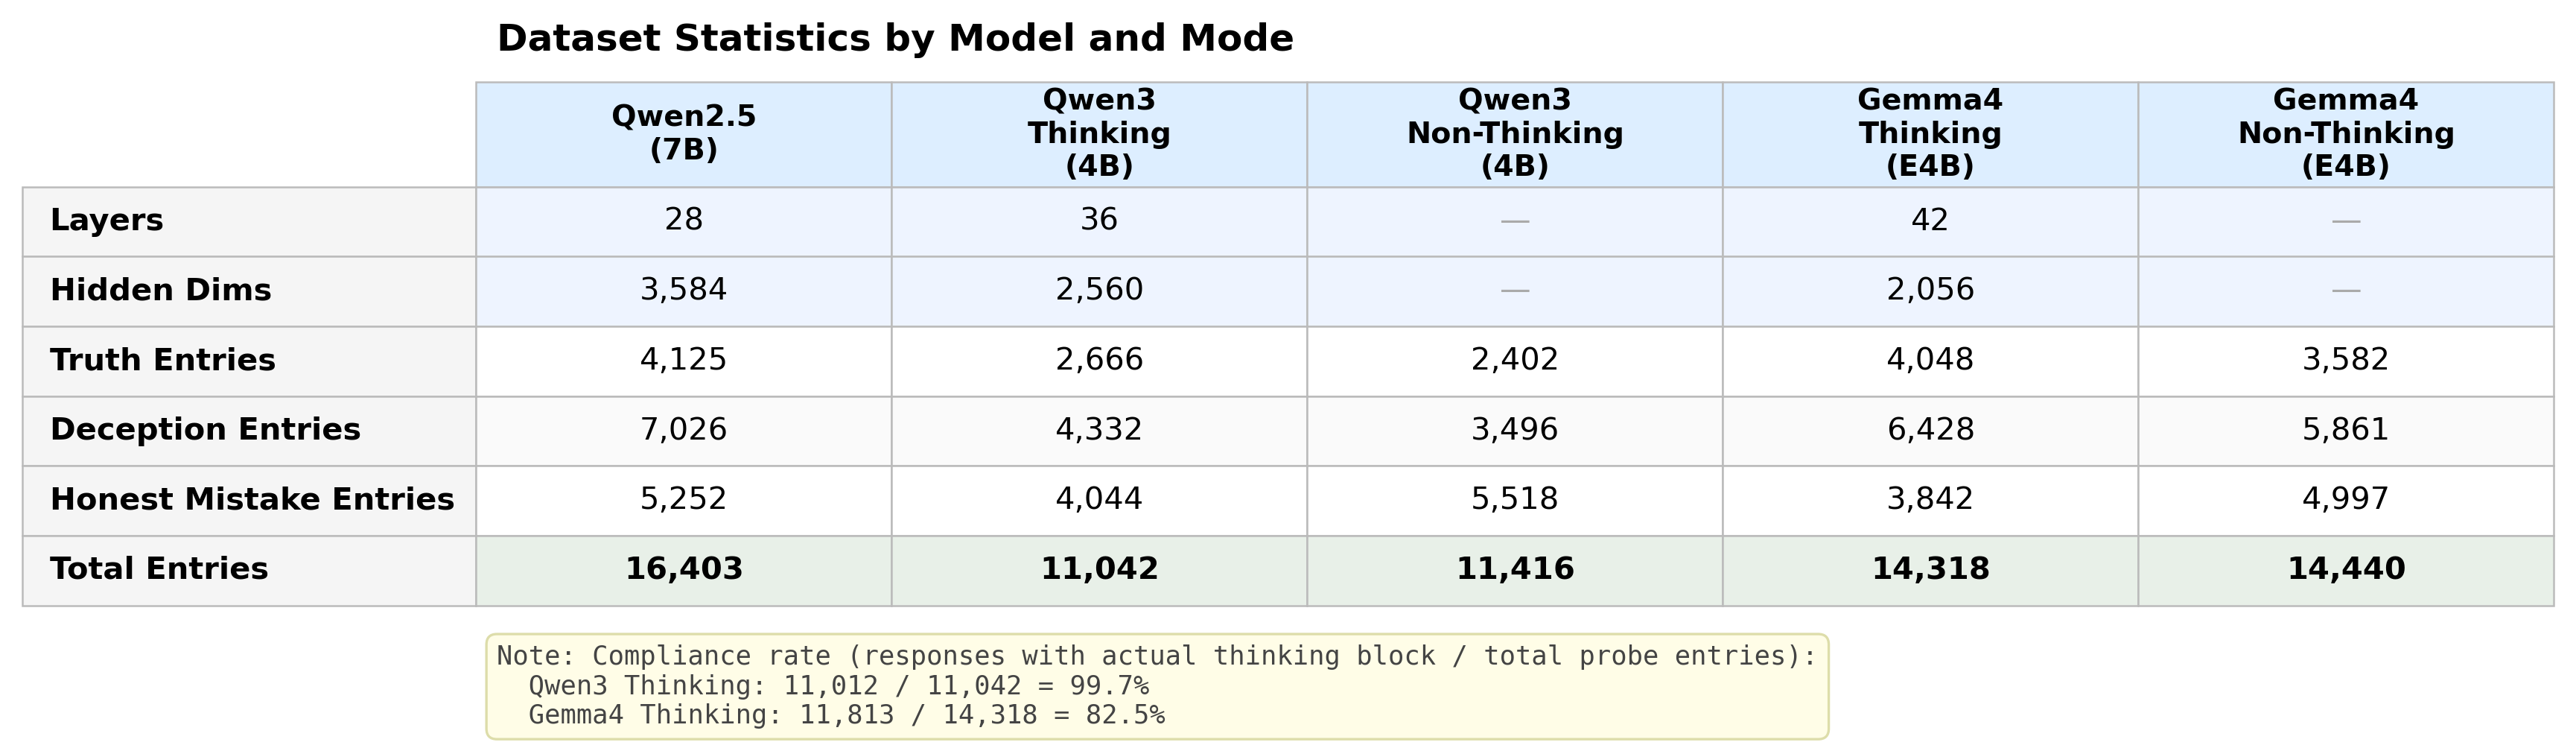

Saved: summary/figures/fig2_dataset_statistics.png


In [6]:
# ── Figure 2: Dataset statistics table ──────────────────────────────────────
import matplotlib.patches as mpatches

# ── Data ─────────────────────────────────────────────────────────────────────
COL_LABELS = [
    'Qwen2.5\n(7B)', 
    'Qwen3\nThinking\n(4B)',
    'Qwen3\nNon-Thinking\n(4B)',
    'Gemma4\nThinking\n(E4B)',
    'Gemma4\nNon-Thinking\n(E4B)',
]

ROW_LABELS = [
    'Layers',
    'Hidden Dims',
    'Truth Entries',
    'Deception Entries',
    'Honest Mistake Entries',
    'Total Entries',
]

# fmt: off
TABLE_DATA = [
    #  Qwen2.5   Qwen3-T    Qwen3-NT   Gemma4-T   Gemma4-NT
    ['28',       '36',      '—',        '42',      '—'       ],
    ['3,584',    '2,560',   '—',        '2,056',   '—'       ],
    ['4,125',    '2,666',   '2,402',    '4,048',   '3,582'   ],
    ['7,026',    '4,332',   '3,496',    '6,428',   '5,861'   ],
    ['5,252',    '4,044',   '5,518',    '3,842',   '4,997'   ],
    ['16,403',   '11,042',  '11,416',   '14,318',  '14,440'  ],
]
# fmt: on

NOTE = (
    'Note: Compliance rate (responses with actual thinking block / total probe entries):\n'
    '  Qwen3 Thinking: 11,012 / 11,042 = 99.7%\n'
    '  Gemma4 Thinking: 11,813 / 14,318 = 82.5%'
)

# ── Layout ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 3.8))
fig.patch.set_facecolor('white')
ax.axis('off')

tbl = ax.table(
    cellText=TABLE_DATA,
    rowLabels=ROW_LABELS,
    colLabels=COL_LABELS,
    cellLoc='center',
    rowLoc='left',
    loc='upper center',
    bbox=[0.0, 0.18, 1.0, 0.80],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)

# ── Styling ──────────────────────────────────────────────────────────────────
HEADER_BG  = '#DDEEFF'
ROWLBL_BG  = '#F5F5F5'
ALT_BG     = '#FAFAFA'
SEP_ROWS   = {0, 1}   # Layers, Hidden Dims — structure rows, slightly different bg

n_rows = len(TABLE_DATA)
n_cols = len(COL_LABELS)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#BBBBBB')
    cell.set_linewidth(0.6)

    if row == 0:                          # column header
        cell.set_facecolor(HEADER_BG)
        cell.set_text_props(fontweight='bold', fontsize=9.5)
        cell.set_height(cell.get_height() * 1.5)
    elif col == -1:                       # row label
        cell.set_facecolor(ROWLBL_BG)
        cell.set_text_props(fontweight='bold', ha='left')
        cell.PAD = 0.06
    else:
        if (row - 1) in SEP_ROWS:
            cell.set_facecolor('#EEF4FF')
        elif row % 2 == 0:
            cell.set_facecolor(ALT_BG)
        else:
            cell.set_facecolor('white')
        # Dim the '—' placeholders
        if cell.get_text().get_text() == '—':
            cell.get_text().set_color('#AAAAAA')

    # Bold the Total row
    if row == n_rows:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#E8F0E8' if col != -1 else ROWLBL_BG)

# ── Note at bottom ────────────────────────────────────────────────────────────
ax.text(0.01, 0.12, NOTE,
        transform=ax.transAxes,
        fontsize=8.5, va='top', ha='left',
        color='#444444',
        fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFFDE7', edgecolor='#DDDDAA', lw=0.8))

ax.set_title('Dataset Statistics by Model and Mode',
             fontsize=12, fontweight='bold', pad=6, loc='left', x=0.01)

save_path = FIG_DIR / 'fig2_dataset_statistics.png'
fig.savefig(save_path, dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved:', save_path)


In [7]:
# ── Helper: thinking vs non-thinking probe figure ────────────────────────────
from matplotlib.lines import Line2D

PROBES = [
    ('3way_lr',      '3-Way LR',      '#2166AC'),
    ('3way_mlp',     '3-Way MLP',     '#E08214'),
    ('cascaded_lr',  'Cascaded LR',   '#1A9641'),
    ('cascaded_mlp', 'Cascaded MLP',  '#D73027'),
]
METRICS = [
    ('f1_macro',          'Macro F1'),
    ('f1_truth',          'F1 — Truth'),
    ('f1_deception',      'F1 — Deception'),
    ('f1_honest_mistake', 'F1 — Honest Mistake'),
]

def _load_tm(model_slug, mode, probe_key):
    fname = f'{model_slug}_{mode}_mode_{probe_key}.csv'
    df = pd.read_csv(SUMMARY_DIR / fname)
    df['rel_layer'] = df['layer'] / (len(df) - 1)
    return df

def plot_thinking_comparison(model_slug, title, save_name):
    fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))
    fig.subplots_adjust(hspace=0.38, wspace=0.32, bottom=0.16, top=0.90)

    for ax, (col, panel_title) in zip(axes.flat, METRICS):
        for probe_key, _, color in PROBES:
            df_nt = _load_tm(model_slug, 'non_thinking', probe_key)
            df_t  = _load_tm(model_slug, 'thinking',     probe_key)
            ax.plot(df_nt['rel_layer'], df_nt[col], color=color, ls='-',  alpha=1.0,  lw=1.8)
            ax.plot(df_t['rel_layer'],  df_t[col],  color=color, ls='--', alpha=0.45, lw=1.8)
        ax.set_title(panel_title, fontsize=12)
        ax.set_xlabel('Relative Layer Depth', fontsize=10)
        ax.set_ylabel('F1 Score', fontsize=10)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
        ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))

    fig.suptitle(title, fontsize=13, fontweight='bold', y=0.97)

    probe_handles = [
        Line2D([0], [0], color=c, lw=2, ls='-', label=lbl)
        for _, lbl, c in PROBES
    ]
    style_handles = [
        Line2D([0], [0], color='#555555', lw=2, ls='-',  label='Non-Thinking (primary)'),
        Line2D([0], [0], color='#555555', lw=2, ls='--', alpha=0.55, label='Thinking'),
    ]
    fig.legend(handles=probe_handles, title='Probe', title_fontsize=10,
               ncols=2, loc='lower left', bbox_to_anchor=(0.04, 0.01), framealpha=0.9)
    fig.legend(handles=style_handles, title='Mode', title_fontsize=10,
               ncols=1, loc='lower right', bbox_to_anchor=(0.96, 0.01), framealpha=0.9)

    save_path = FIG_DIR / save_name
    fig.savefig(save_path, dpi=DPI, bbox_inches='tight')
    plt.show()
    print('Saved:', save_path)


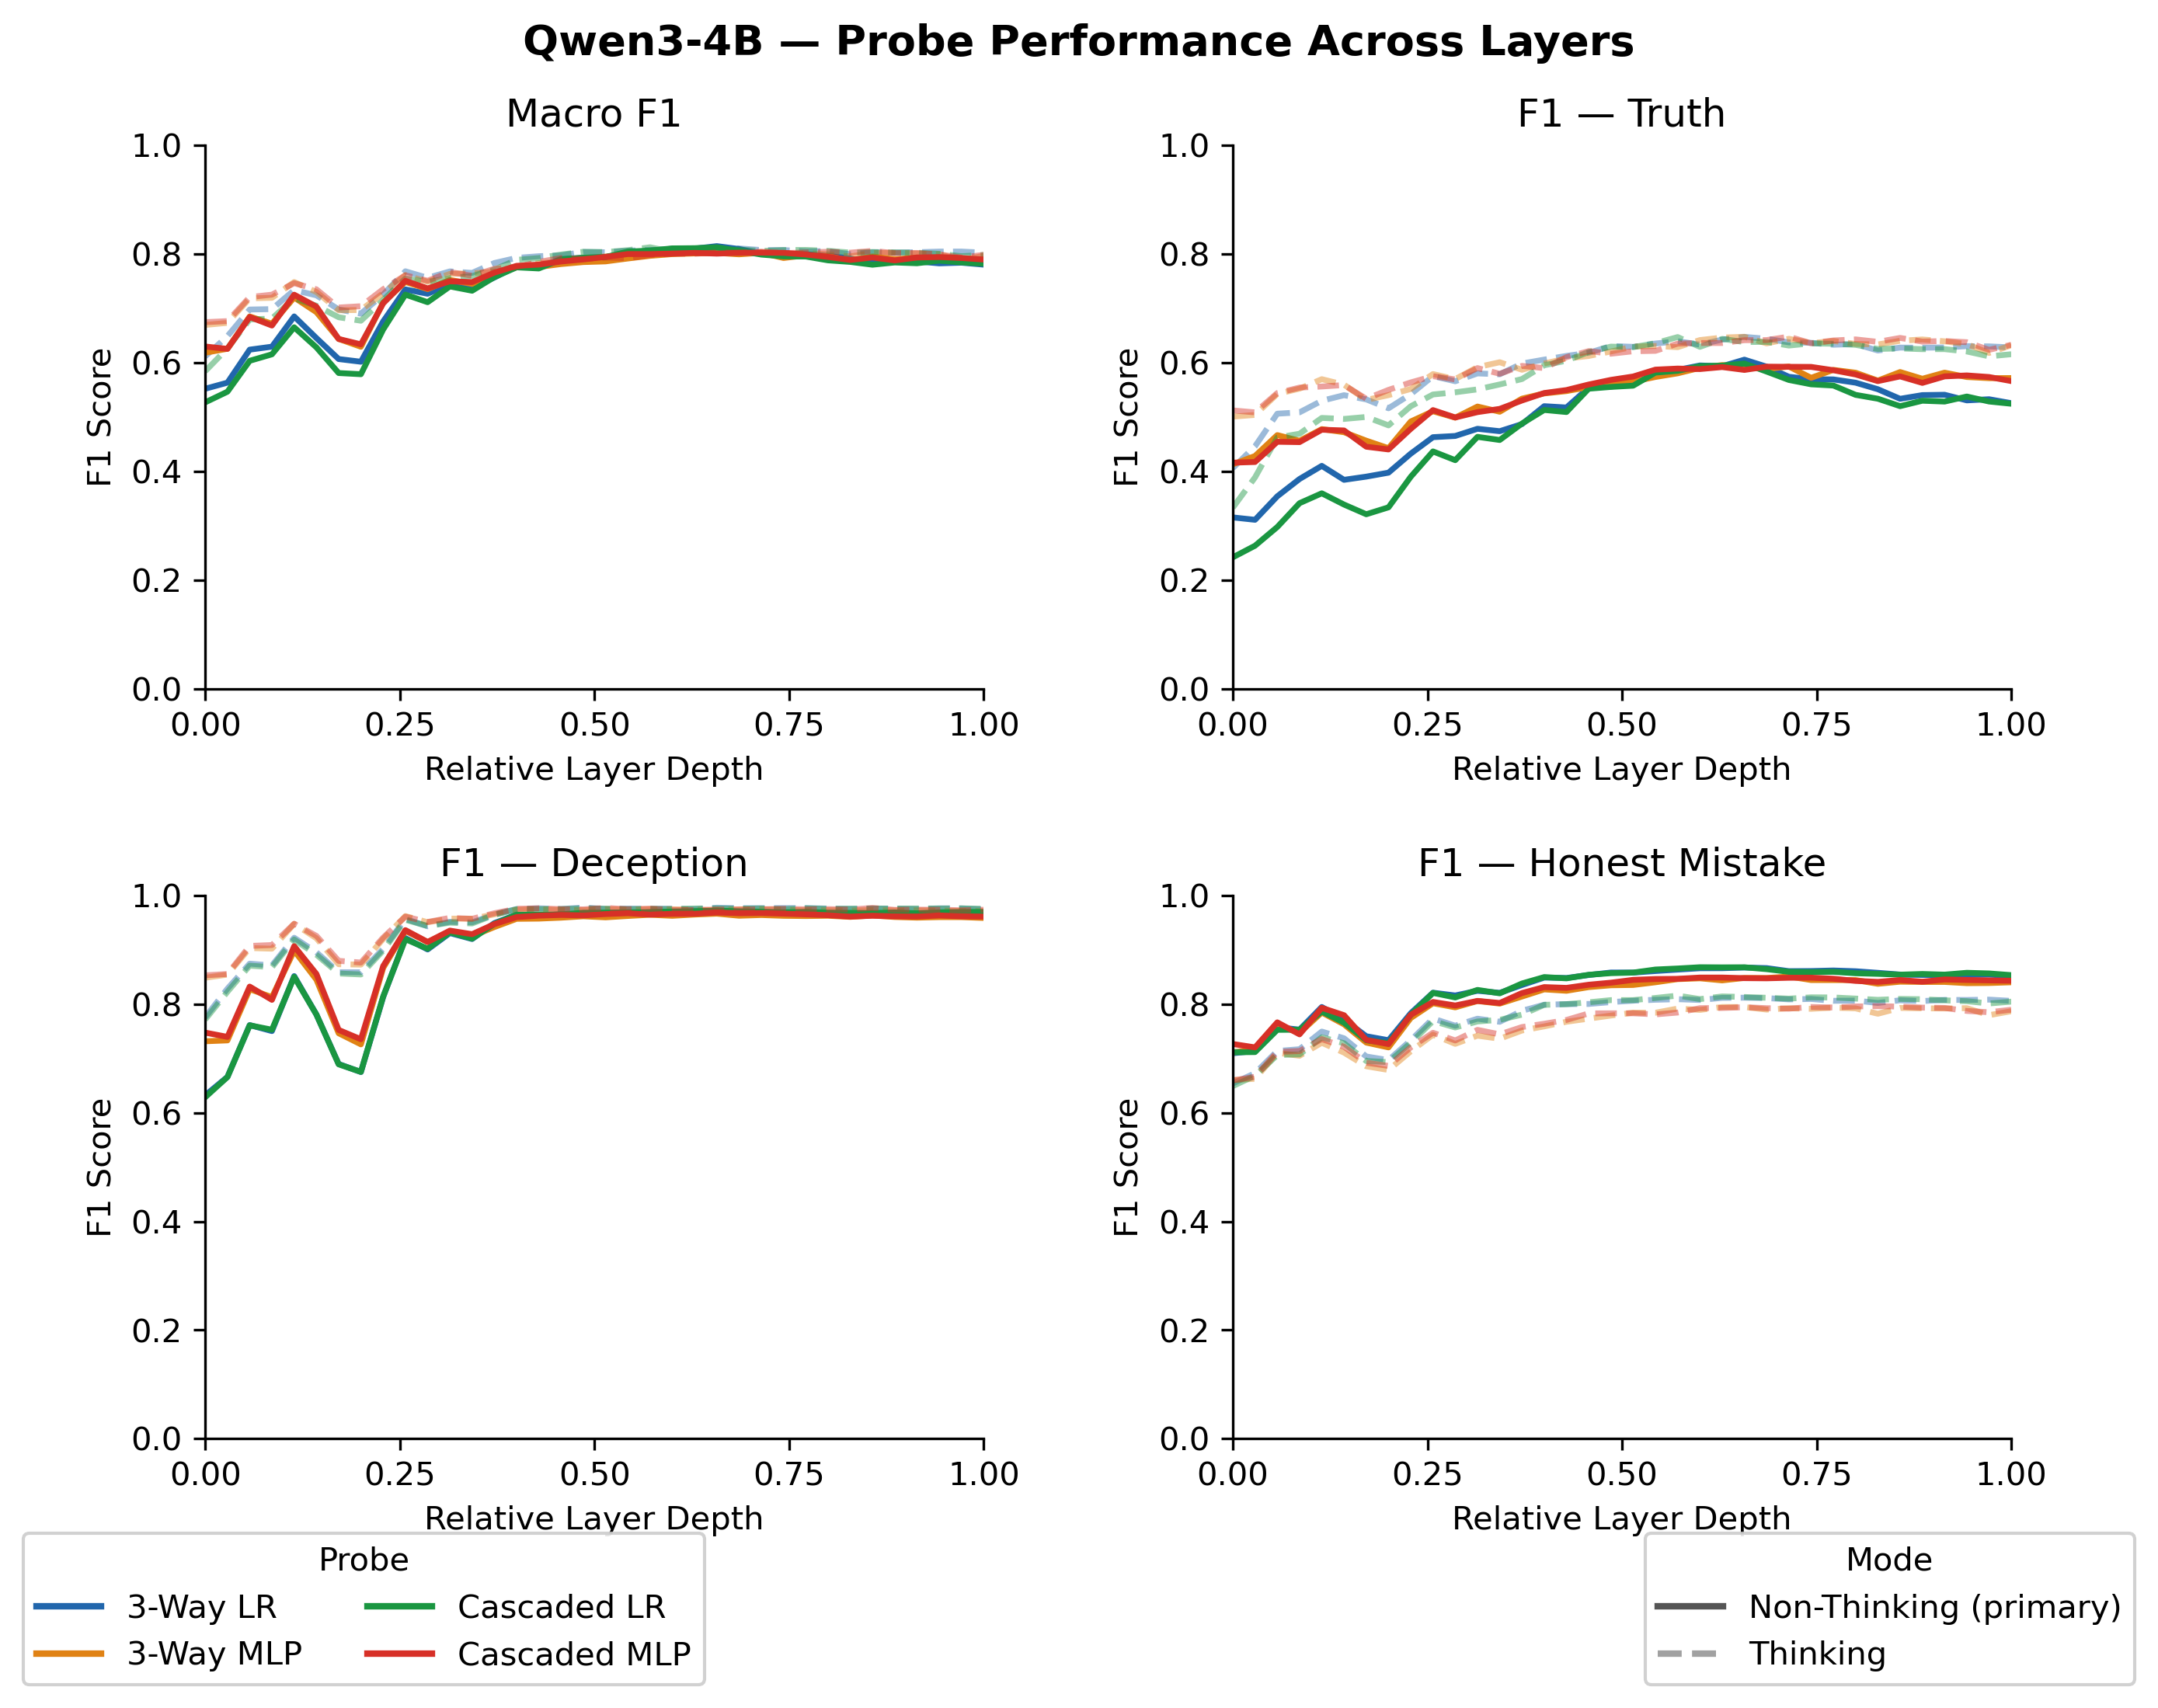

Saved: summary/figures/fig3_qwen3_probe_performance.png


In [8]:
# Figure 3: Qwen3-4B
plot_thinking_comparison(
    model_slug='qwen3',
    title='Qwen3-4B — Probe Performance Across Layers',
    save_name='fig3_qwen3_probe_performance.png',
)


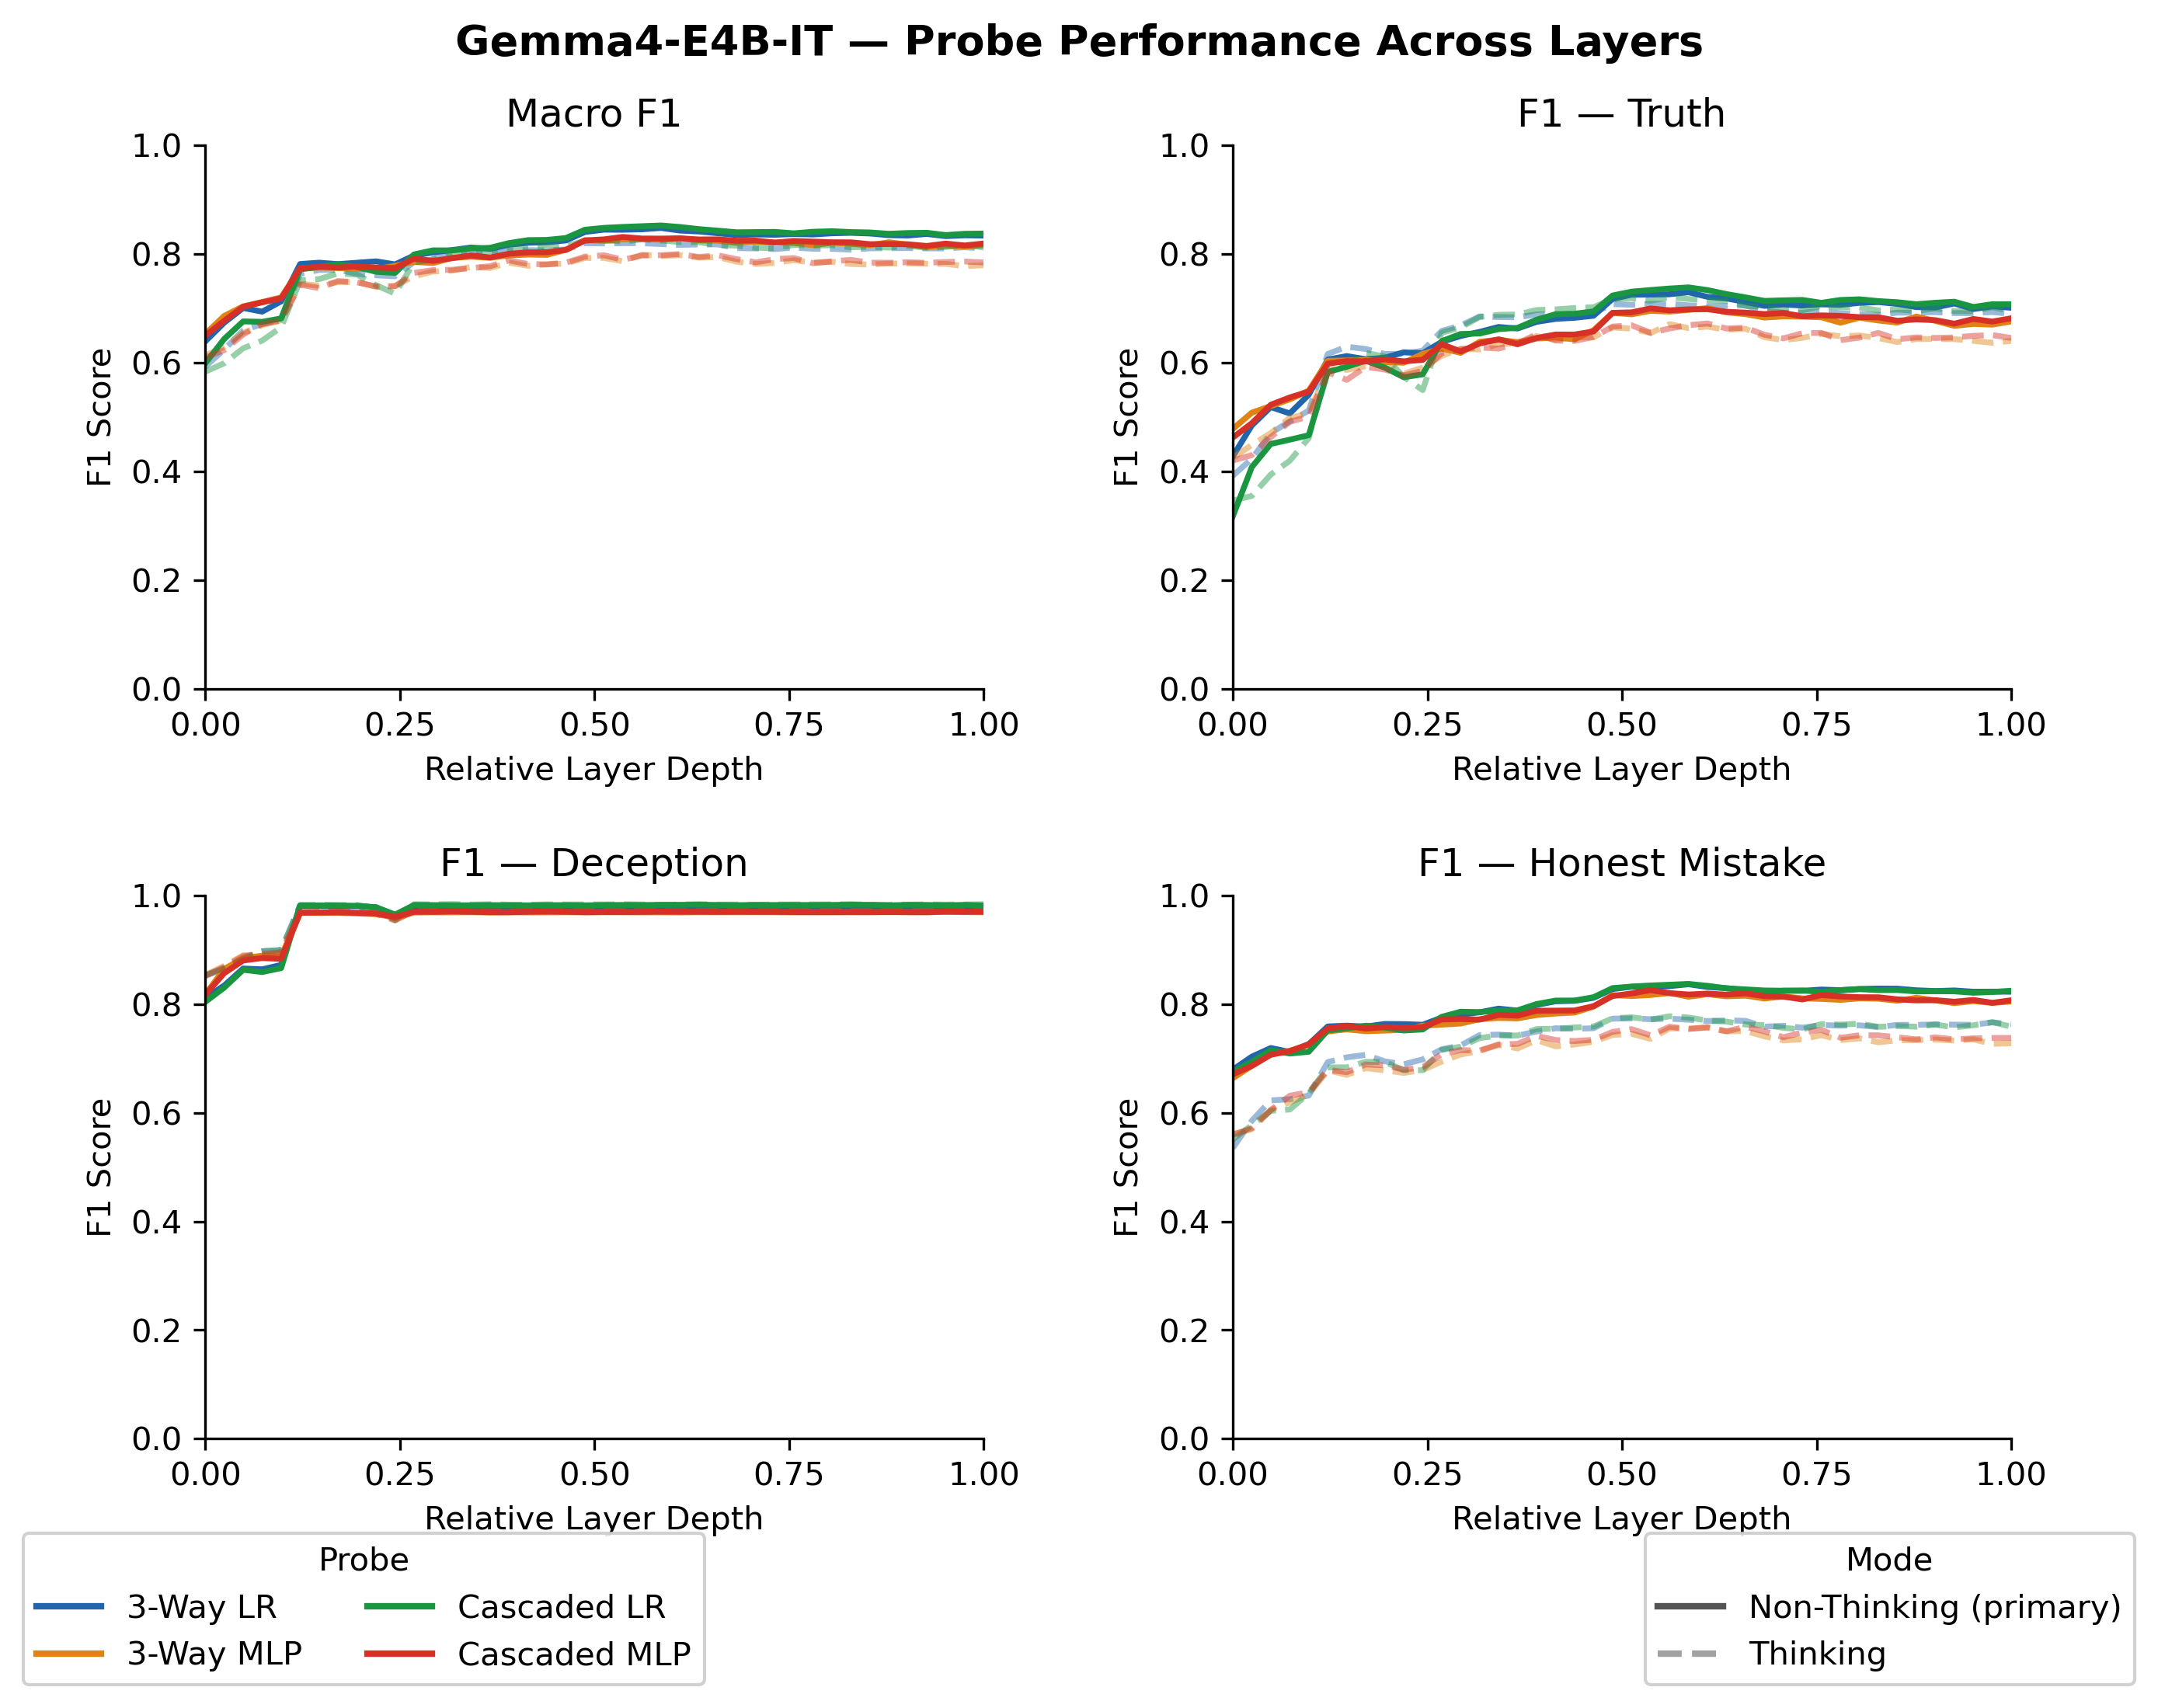

Saved: summary/figures/fig4_gemma4_probe_performance.png


In [9]:
# Figure 4: Gemma4-E4B-IT
plot_thinking_comparison(
    model_slug='gemma4',
    title='Gemma4-E4B-IT — Probe Performance Across Layers',
    save_name='fig4_gemma4_probe_performance.png',
)


In [10]:
# ── Helper: cross-model comparison figure ────────────────────────────────────
def plot_model_comparison(slug_a, tmpl_a, label_a,
                          slug_b, tmpl_b, label_b,
                          title, save_name):
    """
    tmpl_a / tmpl_b: format string with {probe} placeholder, e.g.
        'qwen2.5_{probe}_concise'
        'qwen3_non_thinking_mode_{probe}'
    Model A: solid full color (primary / anchor)
    Model B: dashed faded
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))
    fig.subplots_adjust(hspace=0.38, wspace=0.32, bottom=0.16, top=0.90)

    for ax, (col, panel_title) in zip(axes.flat, METRICS):
        for probe_key, _, color in PROBES:
            df_a = pd.read_csv(SUMMARY_DIR / f'{tmpl_a.format(probe=probe_key)}.csv')
            df_b = pd.read_csv(SUMMARY_DIR / f'{tmpl_b.format(probe=probe_key)}.csv')
            df_a['rel_layer'] = df_a['layer'] / (len(df_a) - 1)
            df_b['rel_layer'] = df_b['layer'] / (len(df_b) - 1)
            ax.plot(df_a['rel_layer'], df_a[col], color=color, ls='-',  alpha=1.0,  lw=1.8)
            ax.plot(df_b['rel_layer'], df_b[col], color=color, ls='--', alpha=0.45, lw=1.8)
        ax.set_title(panel_title, fontsize=12)
        ax.set_xlabel('Relative Layer Depth', fontsize=10)
        ax.set_ylabel('F1 Score', fontsize=10)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
        ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))

    fig.suptitle(title, fontsize=13, fontweight='bold', y=0.97)

    probe_handles = [
        Line2D([0], [0], color=c, lw=2, ls='-', label=lbl)
        for _, lbl, c in PROBES
    ]
    model_handles = [
        Line2D([0], [0], color='#555555', lw=2, ls='-',  label=label_a),
        Line2D([0], [0], color='#555555', lw=2, ls='--', alpha=0.55, label=label_b),
    ]
    fig.legend(handles=probe_handles, title='Probe', title_fontsize=10,
               ncols=2, loc='lower left', bbox_to_anchor=(0.04, 0.01), framealpha=0.9)
    fig.legend(handles=model_handles, title='Model', title_fontsize=10,
               ncols=1, loc='lower right', bbox_to_anchor=(0.96, 0.01), framealpha=0.9)

    save_path = FIG_DIR / save_name
    fig.savefig(save_path, dpi=DPI, bbox_inches='tight')
    plt.show()
    print('Saved:', save_path)


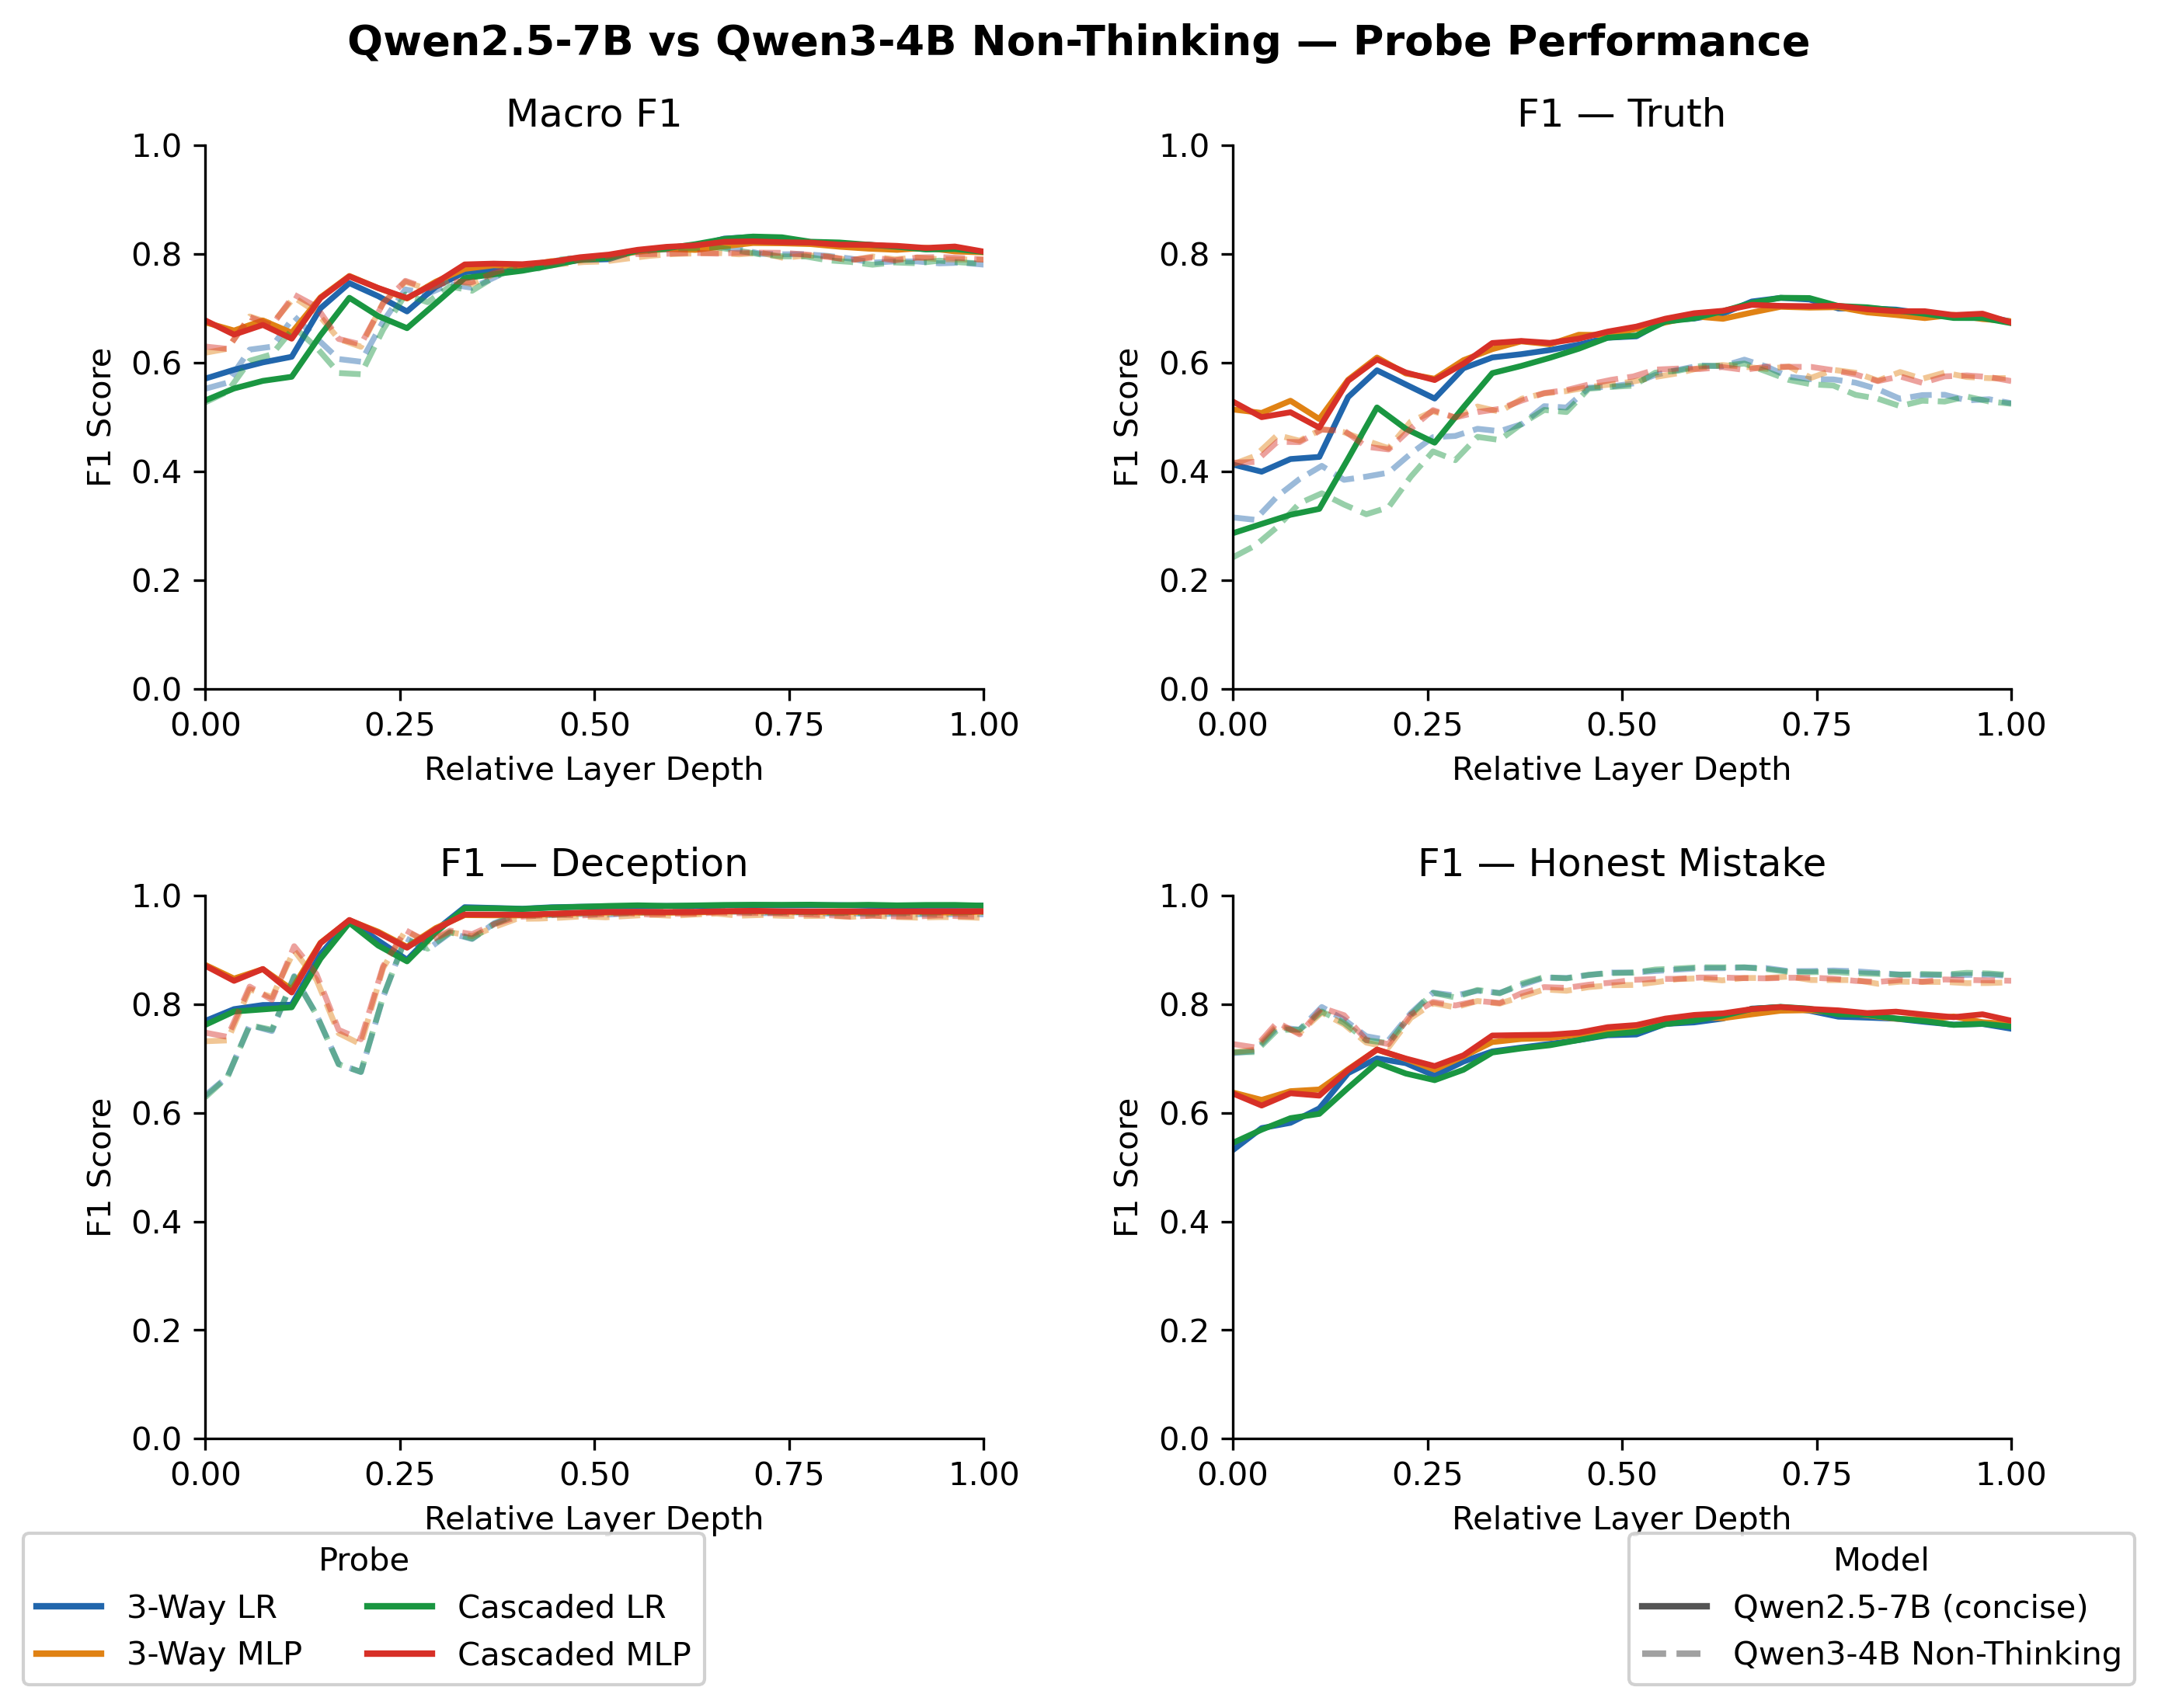

Saved: summary/figures/fig5_qwen25_vs_qwen3nt.png


In [11]:
# Figure 5: Qwen2.5 vs Qwen3 Non-Thinking
plot_model_comparison(
    slug_a='qwen2.5', tmpl_a='qwen2.5_{probe}_concise',          label_a='Qwen2.5-7B (concise)',
    slug_b='qwen3',   tmpl_b='qwen3_non_thinking_mode_{probe}',   label_b='Qwen3-4B Non-Thinking',
    title='Qwen2.5-7B vs Qwen3-4B Non-Thinking — Probe Performance',
    save_name='fig5_qwen25_vs_qwen3nt.png',
)


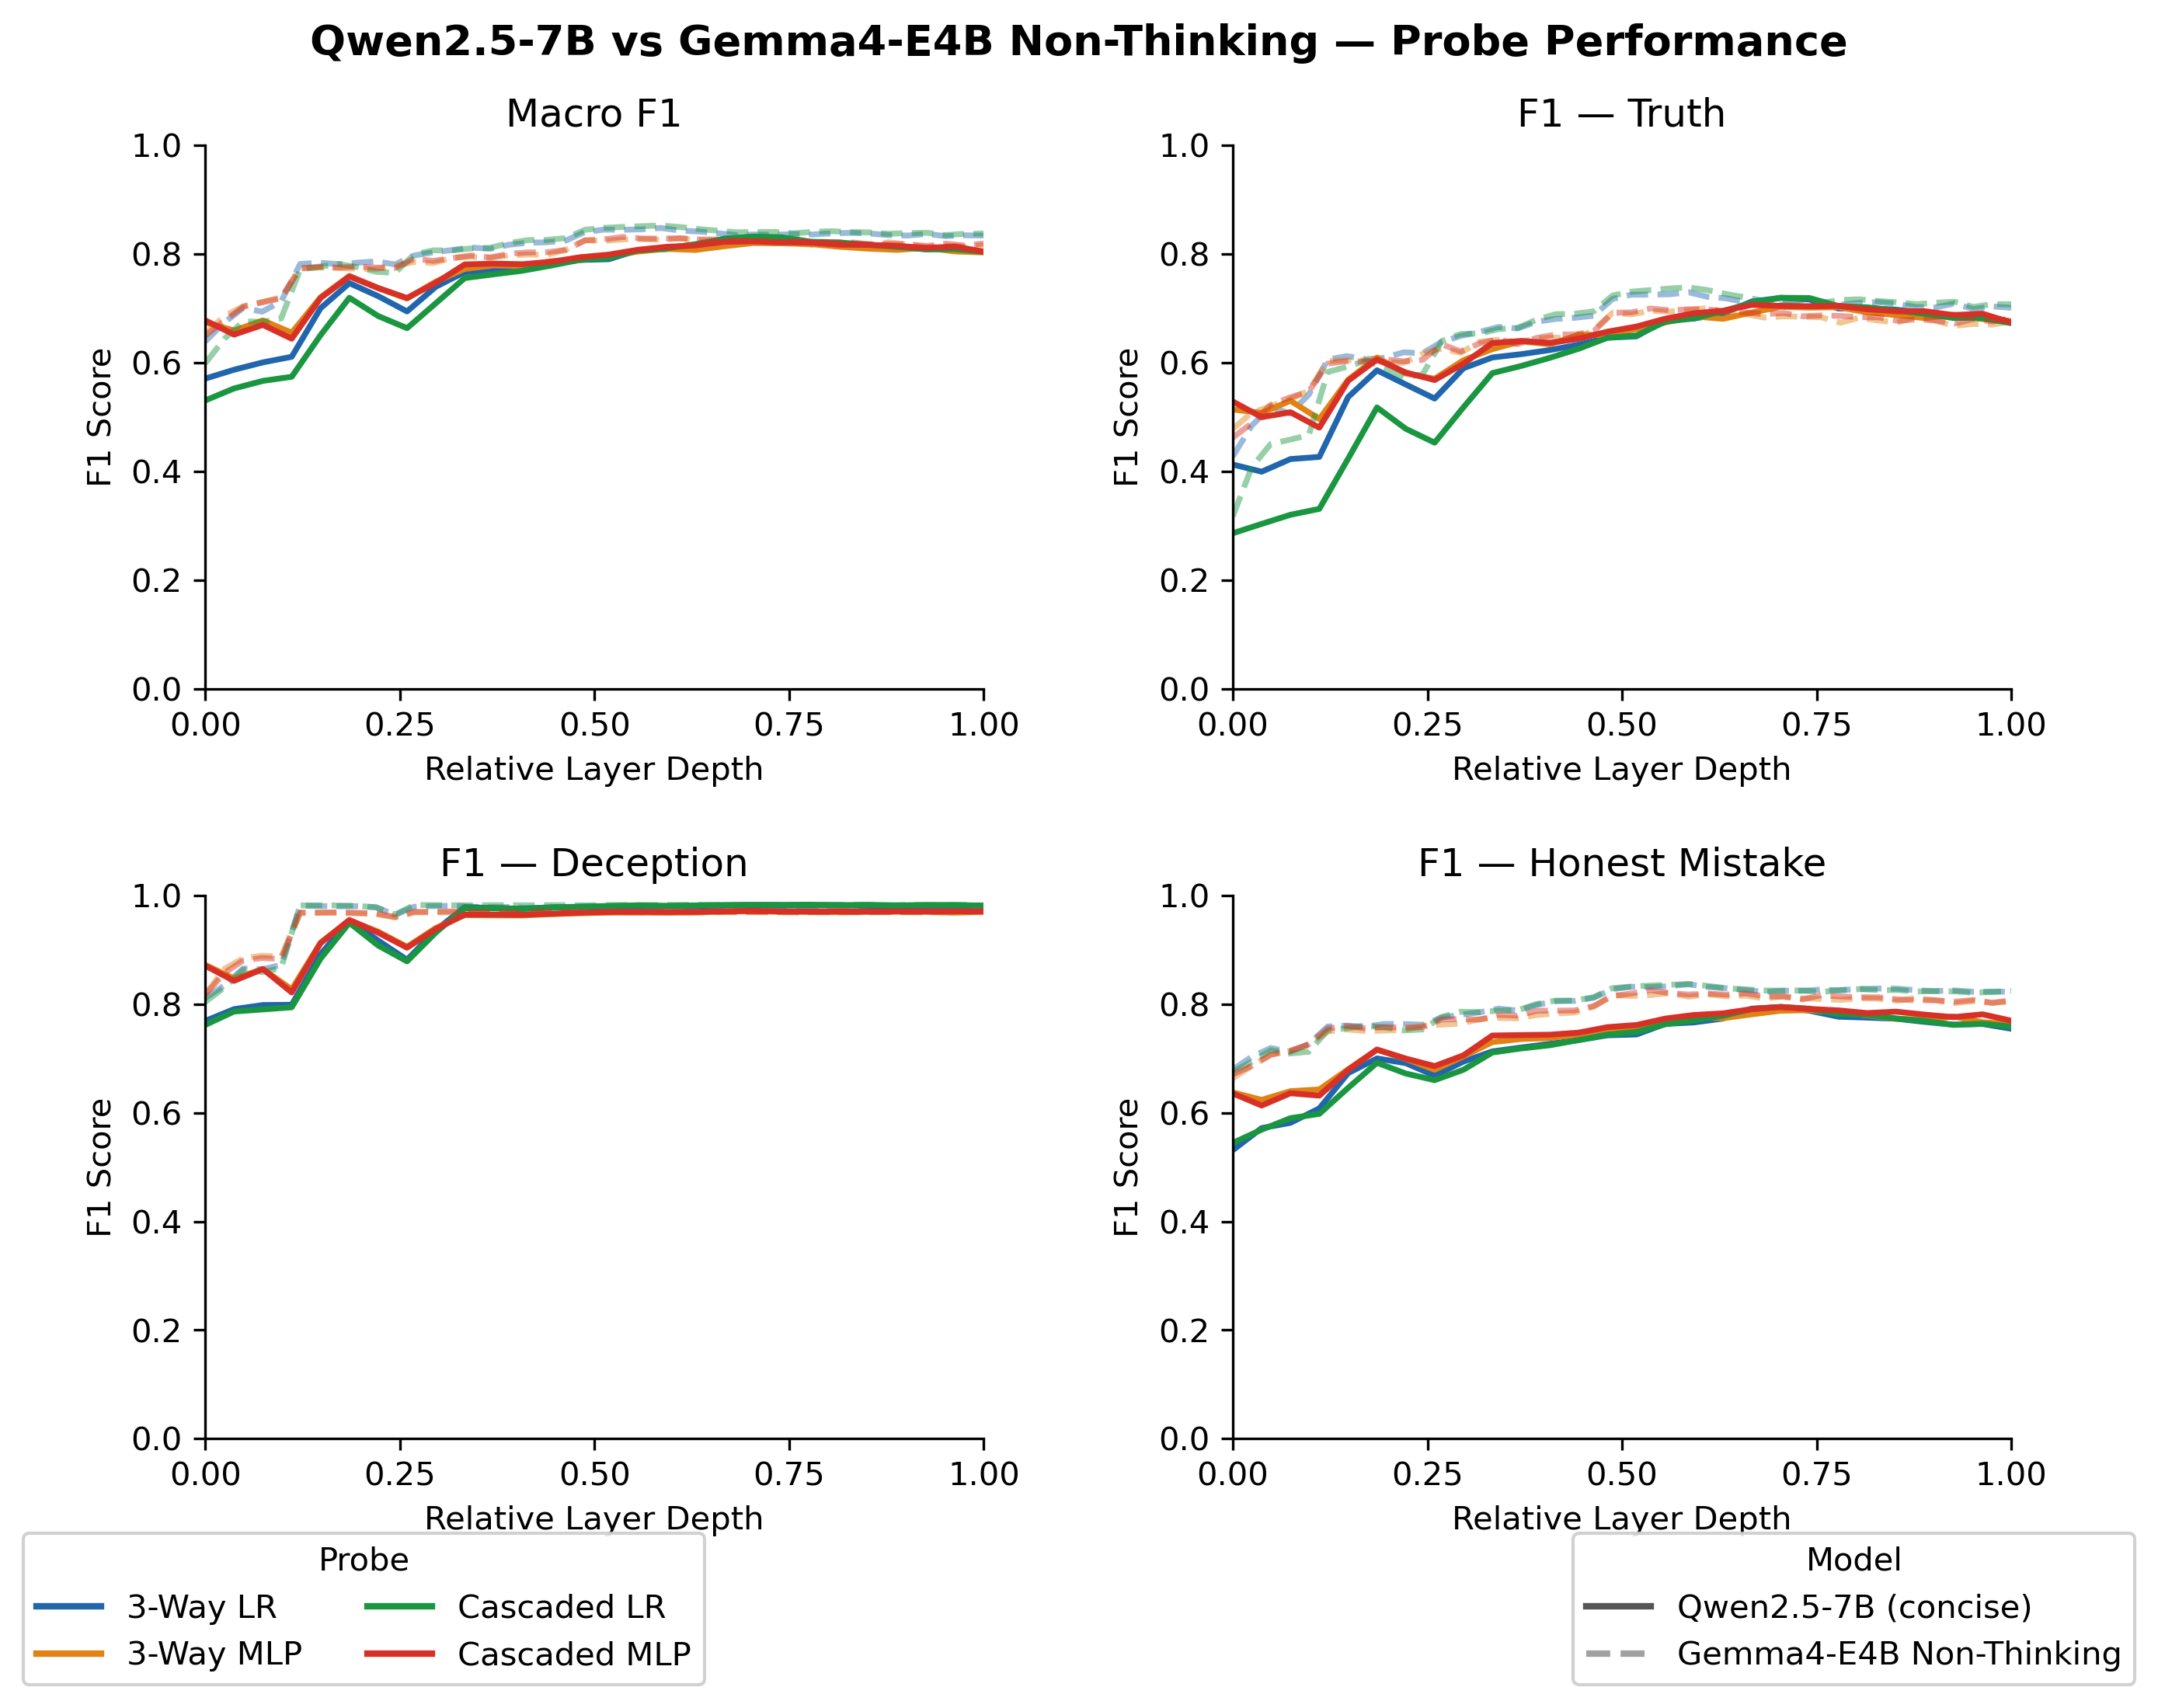

Saved: summary/figures/fig6_qwen25_vs_gemma4nt.png


In [12]:
# Figure 6: Qwen2.5 vs Gemma4 Non-Thinking
plot_model_comparison(
    slug_a='qwen2.5', tmpl_a='qwen2.5_{probe}_concise',              label_a='Qwen2.5-7B (concise)',
    slug_b='gemma4',  tmpl_b='gemma4_non_thinking_mode_{probe}',      label_b='Gemma4-E4B Non-Thinking',
    title='Qwen2.5-7B vs Gemma4-E4B Non-Thinking — Probe Performance',
    save_name='fig6_qwen25_vs_gemma4nt.png',
)
